# BPNL(Buy Now Pay Later) Risk Scoring & Analytics (India)

**| PYTHON Exploratory Data Analysis**

I. Loading Modules.

In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

II. Loading the CSV File.

In [206]:
df = pd.read_csv('/content/bpnl.csv').sort_values('S_no')
df

,S_no,User_id,Lending_company,Age,City,State,Monthly_income,Loan_amount,Reason,Credit_limit,Tenure_months,Year,Transactions_per_month,Missed_Payments,Repayment_Method,Credit_utilization_ratio,Default_risk
10733,1,233044,PaySense,25,Chennai,Tamil Nadu,36764,305304.631876,Vehicle Loan,24077,5,2025,7,2,Debit Card,0.461735,6
64628,2,894361,ZestMoney,25,Kochi,Kerala,13930,46380.811951,Vehicle Loan,29178,14,2022,5,4,Credit Card,0.625266,3
40323,3,594950,ZestMoney,22,Ahmedabad,Gujarat,75487,249823.904759,Home P&C Loan,30431,18,2024,5,0,Credit Card,0.452116,8
55054,4,775841,Simpl,46,Kochi,Kerala,33552,85540.457923,Electronics,61093,5,2024,24,4,Net Banking,0.471355,7
67029,5,925283,LazyPay,27,Lucknow,Uttar Pradesh,56777,123562.123184,Travel & Vacation,91339,19,2024,24,1,UPI/Wallet,0.490594,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6502,73206,180378,LazyPay,58,Delhi,Delhi,25356,212065.704057,Home P&C Loan,75273,1,2023,24,2,UPI/Wallet,0.144292,3
63409,73207,879268,Simpl,50,Delhi,Delhi,87627,208170.632703,Home P&C Loan,71387,20,2023,30,2,Net Banking,0.548311,6
69350,73208,953871,ZestMoney,19,Coimbatore,Tamil Nadu,29357,113130.847521,Electronics,23499,16,2025,9,1,Debit Card,0.500213,9
30752,73209,478258,PaySense,22,Pune,Maharashtra,37983,136767.529468,Education Loan,40127,20,2022,7,1,UPI/Wallet,0.856134,8


III. Adding Age Category Column.

In [207]:
df['Age_Category'] = df['Age'].apply(
    lambda x: 'Gen Z' if 18 <= x <= 25
    else 'Millennial' if 26 <= x <= 40
    else 'Boomer' if 41 <= x <= 60
    else 'Old Age')
df

,S_no,User_id,Lending_company,Age,City,State,Monthly_income,Loan_amount,Reason,Credit_limit,Tenure_months,Year,Transactions_per_month,Missed_Payments,Repayment_Method,Credit_utilization_ratio,Default_risk,Age_Category
10733,1,233044,PaySense,25,Chennai,Tamil Nadu,36764,305304.631876,Vehicle Loan,24077,5,2025,7,2,Debit Card,0.461735,6,Gen Z
64628,2,894361,ZestMoney,25,Kochi,Kerala,13930,46380.811951,Vehicle Loan,29178,14,2022,5,4,Credit Card,0.625266,3,Gen Z
40323,3,594950,ZestMoney,22,Ahmedabad,Gujarat,75487,249823.904759,Home P&C Loan,30431,18,2024,5,0,Credit Card,0.452116,8,Gen Z
55054,4,775841,Simpl,46,Kochi,Kerala,33552,85540.457923,Electronics,61093,5,2024,24,4,Net Banking,0.471355,7,Boomer
67029,5,925283,LazyPay,27,Lucknow,Uttar Pradesh,56777,123562.123184,Travel & Vacation,91339,19,2024,24,1,UPI/Wallet,0.490594,4,Millennial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6502,73206,180378,LazyPay,58,Delhi,Delhi,25356,212065.704057,Home P&C Loan,75273,1,2023,24,2,UPI/Wallet,0.144292,3,Boomer
63409,73207,879268,Simpl,50,Delhi,Delhi,87627,208170.632703,Home P&C Loan,71387,20,2023,30,2,Net Banking,0.548311,6,Boomer
69350,73208,953871,ZestMoney,19,Coimbatore,Tamil Nadu,29357,113130.847521,Electronics,23499,16,2025,9,1,Debit Card,0.500213,9,Gen Z
30752,73209,478258,PaySense,22,Pune,Maharashtra,37983,136767.529468,Education Loan,40127,20,2022,7,1,UPI/Wallet,0.856134,8,Gen Z


IV. Discovering Data.

In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73210 entries, 10733 to 884
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   S_no                      73210 non-null  int64  
 1   User_id                   73210 non-null  int64  
 2   Lending_company           73210 non-null  object 
 3   Age                       73210 non-null  int64  
 4   City                      73210 non-null  object 
 5   State                     73210 non-null  object 
 6   Monthly_income            73210 non-null  int64  
 7   Loan_amount               73210 non-null  float64
 8   Reason                    73210 non-null  object 
 9   Credit_limit              73210 non-null  int64  
 10  Tenure_months             73210 non-null  int64  
 11  Year                      73210 non-null  int64  
 12  Transactions_per_month    73210 non-null  int64  
 13  Missed_Payments           73210 non-null  int64  
 14  Repayment

In [209]:
df.shape

(73210, 18)

In [210]:
df.describe()

,S_no,User_id,Age,Monthly_income,Loan_amount,Credit_limit,Tenure_months,Year,Transactions_per_month,Missed_Payments,Credit_utilization_ratio,Default_risk
count,73210.000000,73210.000000,73210.000000,73210.000000,73210.000000,73210.000000,73210.000000,73210.000000,73210.000000,73210.000000,73210.000000,73210.000000
mean,36605.500000,550199.521568,34.504344,54772.663693,181401.045055,77053.447070,11.922838,2023.507007,22.066179,2.012184,0.533946,4.995424
std,21134.050941,259286.197169,15.526847,25874.981565,106143.981036,36410.289505,6.666314,1.116504,9.006951,1.424603,0.249343,2.583780
min,1.000000,100009.000000,18.000000,8807.000000,16266.117798,12000.000000,1.000000,2022.000000,5.000000,0.000000,0.096195,1.000000
25%,18303.250000,326812.000000,22.000000,32725.250000,103149.744044,35659.250000,6.000000,2023.000000,11.000000,1.000000,0.317443,3.000000
50%,36605.500000,549520.000000,29.000000,54369.500000,159008.871582,89022.000000,12.000000,2024.000000,26.000000,2.000000,0.529072,5.000000
75%,54907.750000,773784.500000,43.000000,76985.500000,236734.559198,107541.750000,18.000000,2025.000000,29.000000,3.000000,0.750320,7.000000
max,73210.000000,999991.000000,80.000000,117923.000000,442663.878680,128249.000000,23.000000,2025.000000,31.000000,4.000000,0.950000,9.000000


In [211]:
df.head()

,S_no,User_id,Lending_company,Age,City,State,Monthly_income,Loan_amount,Reason,Credit_limit,Tenure_months,Year,Transactions_per_month,Missed_Payments,Repayment_Method,Credit_utilization_ratio,Default_risk,Age_Category
10733,1,233044,PaySense,25,Chennai,Tamil Nadu,36764,305304.631876,Vehicle Loan,24077,5,2025,7,2,Debit Card,0.461735,6,Gen Z
64628,2,894361,ZestMoney,25,Kochi,Kerala,13930,46380.811951,Vehicle Loan,29178,14,2022,5,4,Credit Card,0.625266,3,Gen Z
40323,3,594950,ZestMoney,22,Ahmedabad,Gujarat,75487,249823.904759,Home P&C Loan,30431,18,2024,5,0,Credit Card,0.452116,8,Gen Z
55054,4,775841,Simpl,46,Kochi,Kerala,33552,85540.457923,Electronics,61093,5,2024,24,4,Net Banking,0.471355,7,Boomer
67029,5,925283,LazyPay,27,Lucknow,Uttar Pradesh,56777,123562.123184,Travel & Vacation,91339,19,2024,24,1,UPI/Wallet,0.490594,4,Millennial


In [212]:
# Lending Companies in Dataset.

print(df['Lending_company'].unique())
df['Lending_company'].nunique()

['PaySense' 'ZestMoney' 'Simpl' 'LazyPay' 'Slice' 'FlexSalary' 'KreditBee'
 'CASHe' 'MoneyTap' 'EarlySalary']


10

In [213]:
# Reasons for taking Loan.

print(df['Reason'].unique())
df['Reason'].nunique()

['Vehicle Loan' 'Home P&C Loan' 'Electronics' 'Travel & Vacation'
 'Medical Loan' 'Education Loan']


6

In [214]:
# States in Dataset.

print(df['State'].unique())
df['State'].nunique()

['Tamil Nadu' 'Kerala' 'Gujarat' 'Uttar Pradesh' 'Telangana' 'Maharashtra'
 'Himachal Pradesh' 'West Bengal' 'Delhi' 'Karnataka' 'Madhya Pradesh'
 'Sikkim' 'Bihar' 'Andaman and Nicobar Islands' 'Chhattisgarh' 'Manipur'
 'Ladakh' 'Rajasthan' 'Mizoram' 'Chandigarh' 'Jharkhand']


21

In [215]:
# Cities in Dataset.

print(df['City'].unique())
df['City'].nunique()

['Chennai' 'Kochi' 'Ahmedabad' 'Lucknow' 'Hyderabad' 'Mumbai' 'Shimla'
 'Kolkata' 'Delhi' 'Bangalore' 'Indore' 'Pune' 'Ujjain' 'Bhopal' 'Gangtok'
 'Nagpur' 'Patna' 'Agra' 'Jabalpur' 'Gwalior' 'Port Blair' 'Surat'
 'Raipur' 'Coimbatore' 'Imphal' 'Leh' 'Jaipur' 'Aizawl' 'Chandigarh'
 'Ranchi']


30

V. EDA using Numpy.

In [216]:
#1. Find the mean, median, and standard deviation of Loan Amount.

loan_amt = np.array(df['Loan_amount'])

mean_loan = np.mean(loan_amt)
median_loan = np.median(loan_amt)
std_loan = np.std(loan_amt)

print("Mean Loan Amount:", mean_loan)
print("Median Loan Amount:", median_loan)
print("Standard Deviation:", std_loan)

Mean Loan Amount: 181401.0450545284
Median Loan Amount: 159008.87158233294
Standard Deviation: 106143.25610523354


In [217]:
#2. Calculate the minimum and maximum Monthly Income.

income = np.array(df['Monthly_income'])

min_income = np.min(income)
max_income = np.max(income)

print("Minimum Monthly Income:", min_income)
print("Maximum Monthly Income:", max_income)

Minimum Monthly Income: 8807
Maximum Monthly Income: 117923


In [218]:
#3. Find the 25th, 50th, and 75th percentile of Credit Utilization Ratio.

credit = np.array(df['Credit_utilization_ratio'])

percentiles = np.percentile(credit, [25, 50, 75])

print("25th Percentile:", percentiles[0])
print("50th Percentile (Median):", percentiles[1])
print("75th Percentile:", percentiles[2])

25th Percentile: 0.3174429772425629
50th Percentile (Median): 0.5290716287376048
75th Percentile: 0.7503197643915123


In [219]:
#4. Calculate the variance of Transactions Per Month.

transactions = np.array(df['Transactions_per_month'])
transaction_variance = np.var(transactions)
print("Variance of Transactions Per Month:", transaction_variance)

Variance of Transactions Per Month: 81.12405901381756


In [220]:
#5. Find the correlation coefficient between Loan Amount and Monthly Income.

loan = np.array(df['Loan_amount'])
income = np.array(df['Monthly_income'])

correlation = np.corrcoef(loan, income)

print("Correlation Matrix:")
print(correlation,'\n')
print("Correlation Coefficient:", correlation[0, 1])

Correlation Matrix:
[[ 1.         -0.00487746]
 [-0.00487746  1.        ]] 

Correlation Coefficient: -0.0048774630973845365


VI. EDA using Pandas.

In [221]:
#6. Display only users belonging to Gen Z age group (18–25).

df[(df['Age'] >= 18) & (df['Age'] <= 25)]

,S_no,User_id,Lending_company,Age,City,State,Monthly_income,Loan_amount,Reason,Credit_limit,Tenure_months,Year,Transactions_per_month,Missed_Payments,Repayment_Method,Credit_utilization_ratio,Default_risk,Age_Category
10733,1,233044,PaySense,25,Chennai,Tamil Nadu,36764,305304.631876,Vehicle Loan,24077,5,2025,7,2,Debit Card,0.461735,6,Gen Z
64628,2,894361,ZestMoney,25,Kochi,Kerala,13930,46380.811951,Vehicle Loan,29178,14,2022,5,4,Credit Card,0.625266,3,Gen Z
40323,3,594950,ZestMoney,22,Ahmedabad,Gujarat,75487,249823.904759,Home P&C Loan,30431,18,2024,5,0,Credit Card,0.452116,8,Gen Z
67916,6,935970,Simpl,19,Ahmedabad,Gujarat,64811,217010.523262,Medical Loan,111079,4,2022,26,2,Debit Card,0.480974,5,Gen Z
63648,7,882156,LazyPay,21,Ahmedabad,Gujarat,65925,346583.308229,Vehicle Loan,105718,9,2024,26,2,Credit Card,0.529072,3,Gen Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25248,73203,411249,Simpl,20,Coimbatore,Tamil Nadu,41691,105340.589262,Electronics,109647,12,2022,27,3,Debit Card,0.856134,1,Gen Z
55604,73205,782586,Simpl,21,Indore,Madhya Pradesh,72169,178341.924626,Travel & Vacation,122806,21,2024,29,4,UPI/Wallet,0.519452,5,Gen Z
69350,73208,953871,ZestMoney,19,Coimbatore,Tamil Nadu,29357,113130.847521,Electronics,23499,16,2025,9,1,Debit Card,0.500213,9,Gen Z
30752,73209,478258,PaySense,22,Pune,Maharashtra,37983,136767.529468,Education Loan,40127,20,2022,7,1,UPI/Wallet,0.856134,8,Gen Z


In [222]:
#7. Find the top 10 highest Loan_amount users.

df.sort_values(by='Loan_amount',ascending=False).head(10)

,S_no,User_id,Lending_company,Age,City,State,Monthly_income,Loan_amount,Reason,Credit_limit,Tenure_months,Year,Transactions_per_month,Missed_Payments,Repayment_Method,Credit_utilization_ratio,Default_risk,Age_Category
29385,34205,462406,Slice,19,Delhi,Delhi,79919,442663.878680,Vehicle Loan,106596,17,2023,27,1,Debit Card,0.461735,8,Gen Z
17306,13810,314494,Slice,48,Kolkata,West Bengal,30025,442432.338432,Vehicle Loan,67198,9,2023,24,1,UPI/Wallet,0.740700,2,Boomer
6059,26953,175089,Simpl,21,Bangalore,Karnataka,91214,442374.442050,Vehicle Loan,120386,8,2024,24,1,Credit Card,0.432877,8,Gen Z
66183,12279,914844,ZestMoney,28,Chennai,Tamil Nadu,12685,442294.638619,Home P&C Loan,26138,22,2025,9,2,Credit Card,0.750320,1,Millennial
27422,56647,438358,Slice,22,Chennai,Tamil Nadu,21340,441771.998121,Medical Loan,125711,12,2024,29,0,UPI/Wallet,0.240487,9,Gen Z
17475,22581,316551,Slice,27,Bhopal,Madhya Pradesh,41275,441677.859965,Home P&C Loan,99660,4,2024,30,0,Credit Card,0.153912,4,Millennial
68436,63635,942401,CASHe,27,Surat,Gujarat,92675,441563.669303,Education Loan,27720,3,2025,11,1,Debit Card,0.346301,6,Millennial
39054,21471,579018,Slice,40,Mumbai,Maharashtra,66032,440838.395580,Education Loan,95149,21,2024,26,0,Net Banking,0.577169,3,Millennial
48231,32009,691359,LazyPay,59,Chennai,Tamil Nadu,48253,439811.453923,Travel & Vacation,74491,12,2024,31,3,Debit Card,0.490594,2,Boomer
52800,31984,748264,Slice,32,Ranchi,Jharkhand,33370,439802.051583,Vehicle Loan,89349,3,2022,30,3,UPI/Wallet,0.480974,5,Millennial


In [223]:
#8. Count total users in each City.

df['City'].value_counts()

,count
City,
Mumbai,5509
Bangalore,5357
Kolkata,5353
Delhi,5334
Pune,5323
Ahmedabad,5278
Hyderabad,5228
Chennai,5206
Nagpur,1800


In [224]:
#9. Find the Average Loan Amount for each Lending Company.

df.groupby('Lending_company')['Loan_amount'].mean().sort_values(ascending=False)

,Loan_amount
Lending_company,
Simpl,206447.742972
Slice,205208.458115
LazyPay,205022.056628
KreditBee,166589.010939
ZestMoney,125406.250441
PaySense,86729.165458
EarlySalary,83131.488845
CASHe,81966.247223
FlexSalary,81341.941290


In [225]:
#10. Find users with Maximum Default Risk.

df[df['Default_risk'] == df['Default_risk'].max()]

,S_no,User_id,Lending_company,Age,City,State,Monthly_income,Loan_amount,Reason,Credit_limit,Tenure_months,Year,Transactions_per_month,Missed_Payments,Repayment_Method,Credit_utilization_ratio,Default_risk,Age_Category
10967,11,236112,Simpl,25,Shimla,Himachal Pradesh,59648,156634.107575,Travel & Vacation,118558,17,2023,26,1,Net Banking,0.682983,9,Gen Z
63996,12,886580,ZestMoney,76,Hyderabad,Telangana,85641,83530.552384,Education Loan,20352,8,2024,10,0,Credit Card,0.625266,9,Old Age
7104,23,188151,Simpl,39,Bhopal,Madhya Pradesh,74546,115850.140999,Education Loan,89567,22,2024,31,1,Credit Card,0.461735,9,Millennial
66886,29,923660,Simpl,33,Hyderabad,Telangana,66395,231790.275330,Home P&C Loan,99744,22,2022,30,1,Credit Card,0.950000,9,Millennial
16190,57,300729,LazyPay,22,Gwalior,Madhya Pradesh,45389,155977.579346,Electronics,120538,10,2023,28,1,Credit Card,0.500213,9,Gen Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37977,73180,566192,Slice,24,Jaipur,Rajasthan,81650,254165.108668,Education Loan,108144,8,2025,29,0,Credit Card,0.625266,9,Gen Z
57237,73185,803240,Simpl,19,Hyderabad,Telangana,81149,278271.406503,Electronics,110939,1,2023,25,1,UPI/Wallet,0.153912,9,Gen Z
19570,73193,342467,Simpl,19,Pune,Maharashtra,72406,422056.621904,Home P&C Loan,125011,18,2025,31,2,UPI/Wallet,0.105814,9,Gen Z
69350,73208,953871,ZestMoney,19,Coimbatore,Tamil Nadu,29357,113130.847521,Electronics,23499,16,2025,9,1,Debit Card,0.500213,9,Gen Z


In [226]:
#11. Calculate Average Missed Payments by Repayment Method.

df.groupby('Repayment_Method')['Missed_Payments'].mean()

,Missed_Payments
Repayment_Method,
Credit Card,2.126967
Debit Card,2.147777
Net Banking,1.891820
UPI/Wallet,1.903196


In [227]:
#12. Find the Average Monthly Income State-wise.

df.groupby('State')['Monthly_income'].mean().sort_values(ascending=False)

,Monthly_income
State,
Kerala,56070.556240
Chandigarh,55642.025196
Sikkim,55472.761687
Ladakh,55340.867113
Delhi,55277.030559
Bihar,55240.100000
Uttar Pradesh,55063.439545
West Bengal,54913.680553
Telangana,54884.207154


In [228]:
#13. Find the top 10 Cities with Highest Average Loan Amount.

df.groupby('City')['Loan_amount'].mean().sort_values(ascending=False).head(10)

,Loan_amount
City,
Delhi,287451.383293
Bangalore,286680.312878
Mumbai,286471.686694
Ahmedabad,224282.384615
Chennai,223656.494481
Pune,223011.943269
Hyderabad,222880.435172
Agra,114076.906877
Ujjain,111302.687618


In [229]:
#14. Find relationship between Missed Payments and Default Risk.

df.groupby('Default_risk')['Missed_Payments'].mean().sort_values(ascending=False)

,Missed_Payments
Default_risk,
3,2.032609
7,2.029156
2,2.018390
4,2.018122
6,2.015375
5,2.003593
9,1.998383
8,1.997202
1,1.997074


In [230]:
#15. Find Top 10 users whose Loan Amount exceeds Monthly Income.

Difference = df['Loan_amount'] - df['Monthly_income']
df['Difference'] = Difference
df[df['Loan_amount']>df['Monthly_income']].sort_values(
  by='Difference',ascending=False).head(10)

,S_no,User_id,Lending_company,Age,City,State,Monthly_income,Loan_amount,Reason,Credit_limit,Tenure_months,Year,Transactions_per_month,Missed_Payments,Repayment_Method,Credit_utilization_ratio,Default_risk,Age_Category,Difference
66183,12279,914844,ZestMoney,28,Chennai,Tamil Nadu,12685,442294.638619,Home P&C Loan,26138,22,2025,9,2,Credit Card,0.750320,1,Millennial,429609.638619
27422,56647,438358,Slice,22,Chennai,Tamil Nadu,21340,441771.998121,Medical Loan,125711,12,2024,29,0,UPI/Wallet,0.240487,9,Gen Z,420431.998121
16715,30831,307099,LazyPay,24,Bangalore,Karnataka,9344,422056.621904,Home P&C Loan,103145,21,2024,25,4,Debit Card,0.384779,4,Gen Z,412712.621904
25256,41675,411273,ZestMoney,24,Delhi,Delhi,9458,422056.621904,Education Loan,30554,7,2025,7,4,Net Banking,0.779178,8,Gen Z,412598.621904
61266,612,852951,Slice,19,Mumbai,Maharashtra,9635,422056.621904,Home P&C Loan,119905,22,2025,26,0,Debit Card,0.211629,2,Gen Z,412421.621904
17306,13810,314494,Slice,48,Kolkata,West Bengal,30025,442432.338432,Vehicle Loan,67198,9,2023,24,1,UPI/Wallet,0.740700,2,Boomer,412407.338432
12096,69276,250796,LazyPay,23,Pune,Maharashtra,9727,422056.621904,Travel & Vacation,123654,5,2025,29,2,Debit Card,0.548311,7,Gen Z,412329.621904
72289,62806,988920,Simpl,23,Hyderabad,Telangana,9828,422056.621904,Home P&C Loan,103165,22,2025,26,0,Debit Card,0.211629,6,Gen Z,412228.621904
983,5484,112617,Simpl,18,Bangalore,Karnataka,10078,422056.621904,Home P&C Loan,119642,21,2024,28,4,Debit Card,0.384779,6,Gen Z,411978.621904
58956,22612,824347,LazyPay,18,Hyderabad,Telangana,10094,422056.621904,Home P&C Loan,107119,21,2025,27,4,Debit Card,0.384779,6,Gen Z,411962.621904


In [231]:
#16. Create a new column named Income Category & display users with Highest Incomes.

df['Income_Category'] = np.where(df['Monthly_income'] < 30000,'Low Income',
np.where(df['Monthly_income'] <= 70000,'Middle Income','High Income'))
df[['User_id','Monthly_income',
    'Income_Category']].sort_values(by ='Monthly_income',ascending=False).head(10)

,User_id,Monthly_income,Income_Category
63035,874430,117923,High Income
48411,693777,115012,High Income
32024,493856,114377,High Income
7213,189320,114300,High Income
46185,666817,114029,High Income
14531,281077,112813,High Income
4247,152706,112721,High Income
42148,616421,112688,High Income
8441,204714,112441,High Income
12922,260894,112152,High Income


In [232]:
#17. Count total users in each Age Category.

df['Age_Category'].value_counts()

,count
Age_Category,
Gen Z,30748
Millennial,22695
Boomer,13910
Old Age,5857


In [233]:
#18. Find the Average Credit Utilization Ratio for each Age Category.

df.groupby('Age_Category')['Credit_utilization_ratio'].mean().sort_values(ascending=False)

,Credit_utilization_ratio
Age_Category,
Old Age,0.535108
Millennial,0.534355
Gen Z,0.533788
Boomer,0.533140


In [234]:
#19. Find the Average Loan Amount and Monthly Income by Age Category.

df.groupby('Age_Category')[['Loan_amount',
'Monthly_income']].mean().sort_values(by='Loan_amount',ascending=False)

,Loan_amount,Monthly_income
Age_Category,,
Gen Z,233622.592713,54543.865520
Millennial,170637.113551,54994.353470
Boomer,121021.235219,54855.958950
Old Age,92355.873954,54916.969609


In [235]:
#20. Find Top 10 Cities with the Highest Average Default Risk.

df.groupby('City')['Default_risk'].mean().sort_values(ascending=False).head(10)

,Default_risk
City,
Leh,5.164436
Shimla,5.070698
Lucknow,5.067346
Hyderabad,5.050306
Patna,5.039326
Bhopal,5.038764
Port Blair,5.034996
Kochi,5.034695
Ahmedabad,5.031830


VII. EDA using Matplotlib.

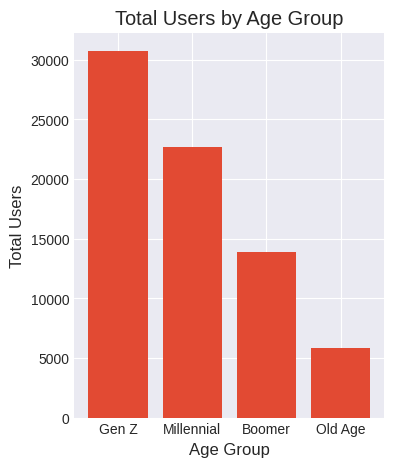

In [236]:
#21. Create a Bar Chart showing total users in each age group.

age_group_count = df['Age_Category'].value_counts()
plt.figure(figsize=(4,5))
plt.style.use("seaborn-v0_8-darkgrid")
plt.bar(age_group_count.index,age_group_count.values)
plt.title('Total Users by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Users')
plt.show()

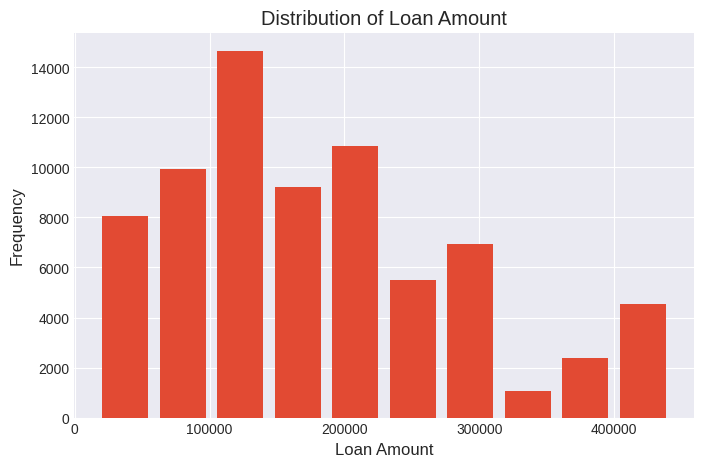

In [237]:
#22. Create a Histogram of Loan Amount.

plt.figure(figsize=(8,5))
plt.hist(df['Loan_amount'],bins=10,rwidth=0.8)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

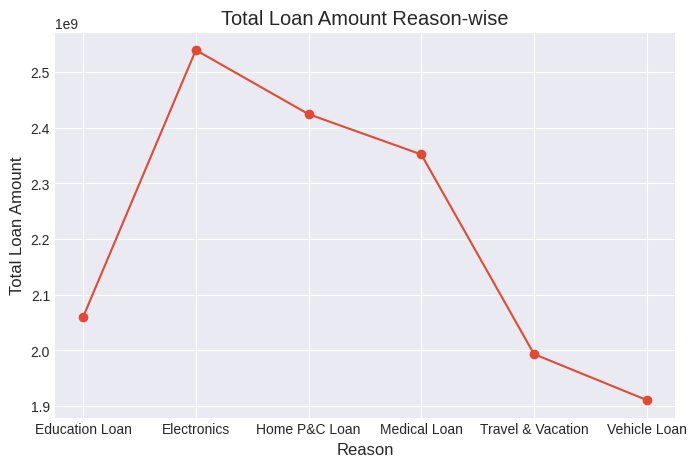

In [238]:
#23. Create a Line Chart showing Total Loan Amount by Reason.

yearly_loan = df.groupby('Reason')['Loan_amount'].sum()
plt.figure(figsize=(8,5))
plt.plot(yearly_loan.index,yearly_loan.values,marker='o')
plt.title('Total Loan Amount Reason-wise')
plt.xlabel('Reason')
plt.ylabel('Total Loan Amount')
plt.grid(True)
plt.show()

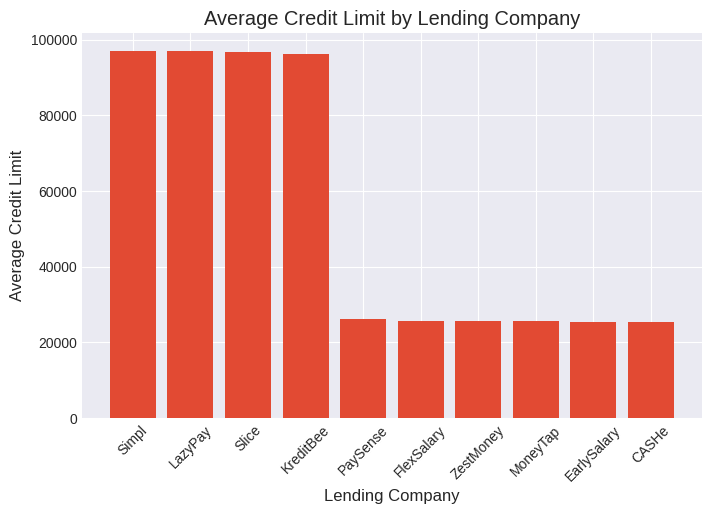

In [239]:
#24. Create a Bar Graph of Top Lending Companies by Average Credit Limit.

avg_credit_limit = df.groupby('Lending_company')[
                  'Credit_limit'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
plt.bar(avg_credit_limit.index,avg_credit_limit.values)
plt.title('Average Credit Limit by Lending Company')
plt.xlabel('Lending Company')
plt.ylabel('Average Credit Limit')
plt.xticks(rotation=45)
plt.show()

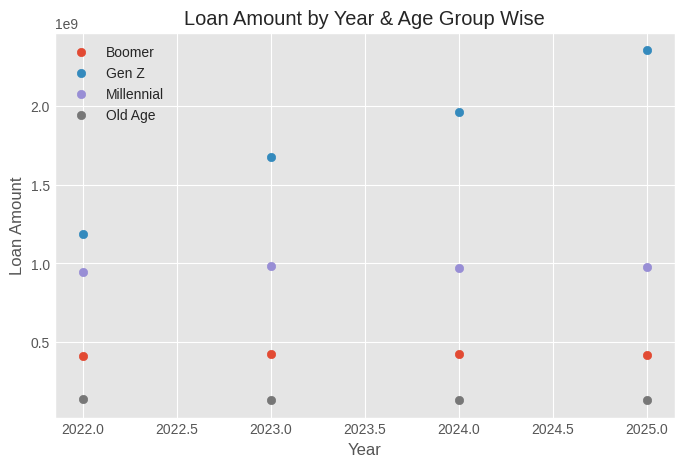

In [240]:
#25. Create a Scatter Plot between Total Loan Amount by Year & Age Group Wise.

year_age_loan = df.groupby(['Year', 'Age_Category'])['Loan_amount'].sum().unstack()

plt.style.use("ggplot")
plt.figure(figsize=(8,5))
for age_group in year_age_loan.columns:
    plt.scatter(
        year_age_loan.index,
        year_age_loan[age_group],
        label=age_group)
plt.title('Loan Amount by Year & Age Group Wise')
plt.xlabel('Year')
plt.ylabel('Loan Amount')
plt.legend()
plt.grid(True)
plt.show()

VIII. EDA using Seaborn.

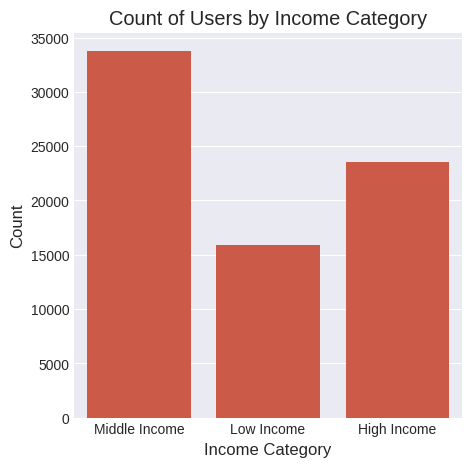

In [241]:
#26. Plot a Countplot for Income Categories.

plt.figure(figsize=(5,5))
plt.style.use("seaborn-v0_8-darkgrid")
sns.countplot(x='Income_Category',data=df)
plt.title('Count of Users by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.show()

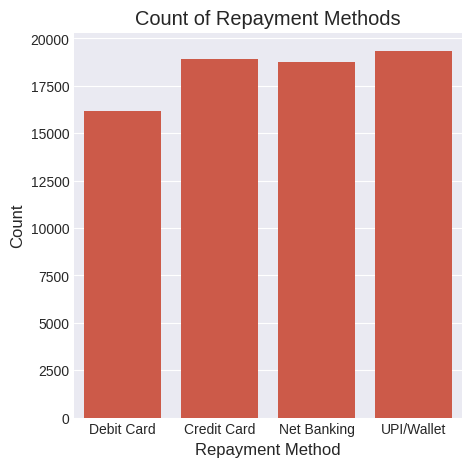

In [242]:
#27. Plot a Countplot for Repayment Method.

plt.figure(figsize=(5,5))
sns.countplot(x='Repayment_Method',data=df)
plt.title('Count of Repayment Methods')
plt.xlabel('Repayment Method')
plt.ylabel('Count')
plt.show()

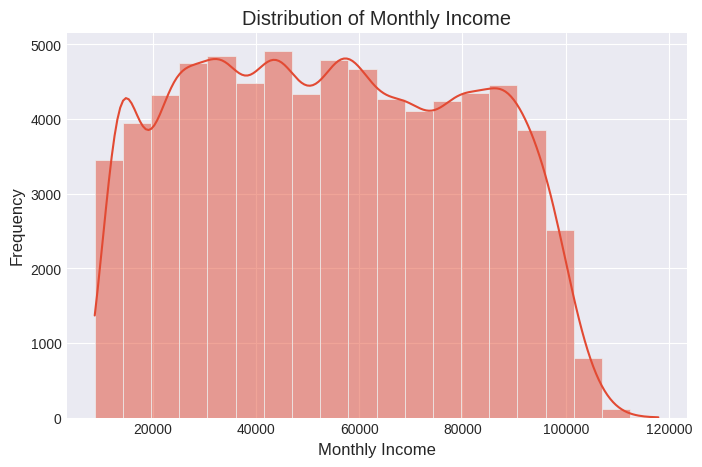

In [243]:
#28. Plot a Histplot for Monthly Income.

plt.figure(figsize=(8,5))
sns.histplot(df['Monthly_income'],bins=20,kde=True)
plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')
plt.show()

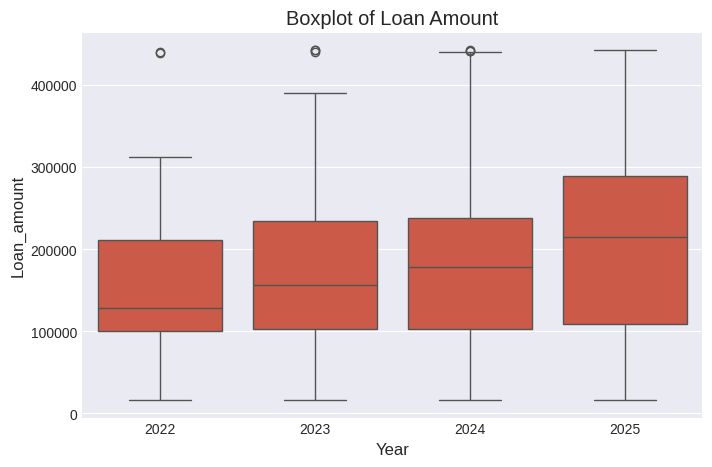

In [244]:
#29. Plot a Boxplot for Loan Amount.

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Year'],y=df['Loan_amount'])
plt.title('Boxplot of Loan Amount')
plt.show()

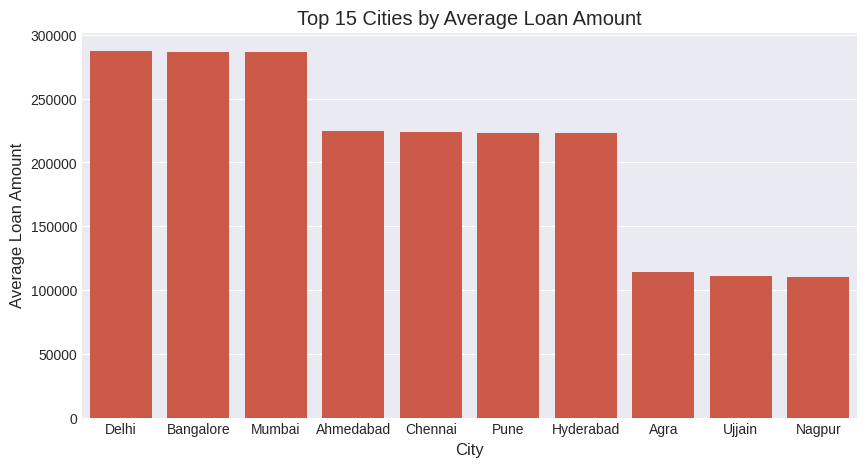

In [245]:
#30. Find Top 15 cities with Highest Average Loan Amount.

plt.figure(figsize=(10,5))
top_city_loan = df.groupby('City')['Loan_amount'].mean().sort_values(
                ascending=False).head(10).reset_index()
sns.barplot(x='City',y='Loan_amount',data=top_city_loan)
plt.title('Top 15 Cities by Average Loan Amount')
plt.xlabel('City')
plt.ylabel('Average Loan Amount')
plt.show()

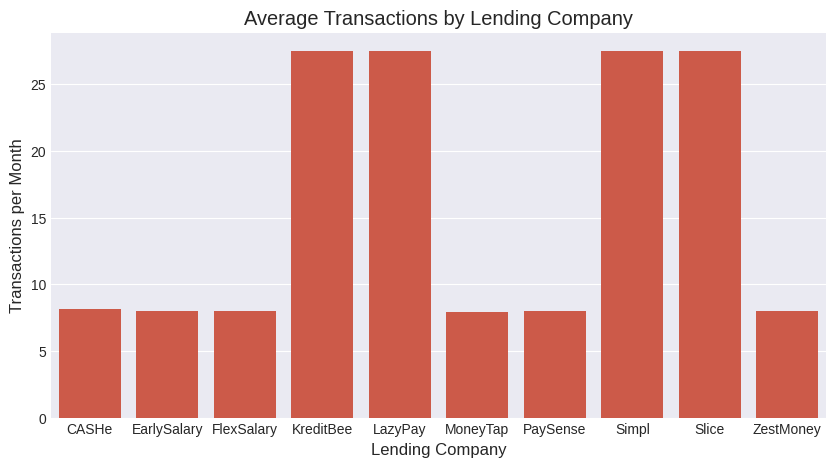

In [246]:
#31. Compare average Transactions Per Month across Lending Companies.

plt.figure(figsize=(10,5))
transaction_company = df.groupby('Lending_company')[
                      'Transactions_per_month'].mean().reset_index()
sns.barplot(x='Lending_company',y='Transactions_per_month',
            data=transaction_company)
plt.title('Average Transactions by Lending Company')
plt.xlabel('Lending Company')
plt.ylabel('Transactions per Month')
plt.show()

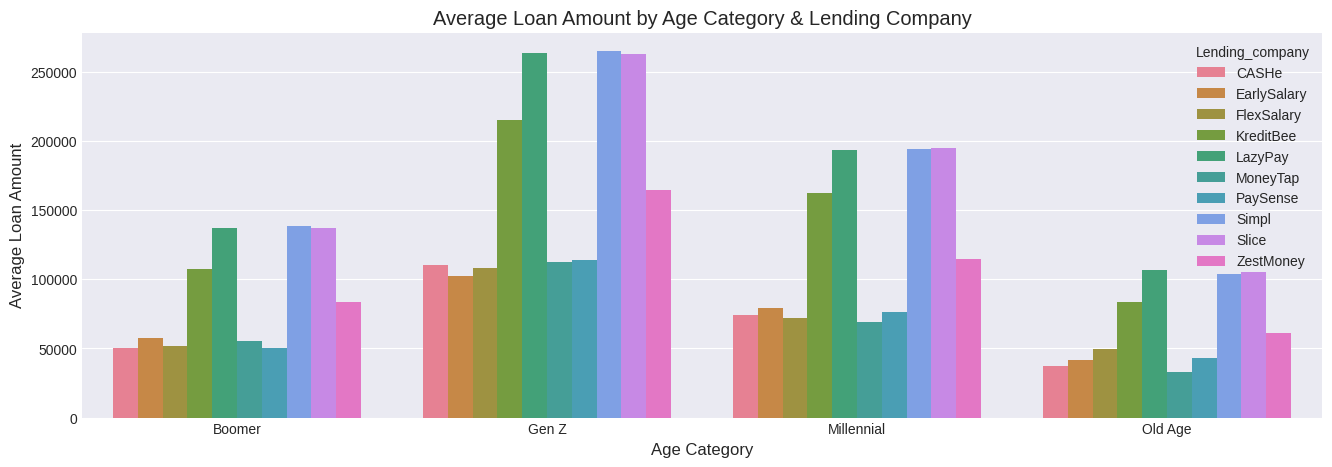

In [247]:
#32. Compare Average Loan Amount across Age Categories and Lending Companies.

plt.figure(figsize=(16,5))
df1 = df.groupby(['Age_Category', 'Lending_company'])[
      'Loan_amount'].mean().reset_index()
sns.barplot(x='Age_Category',y='Loan_amount',hue='Lending_company',data=df1)
plt.title('Average Loan Amount by Age Category & Lending Company')
plt.xlabel('Age Category')
plt.ylabel('Average Loan Amount')
plt.show()

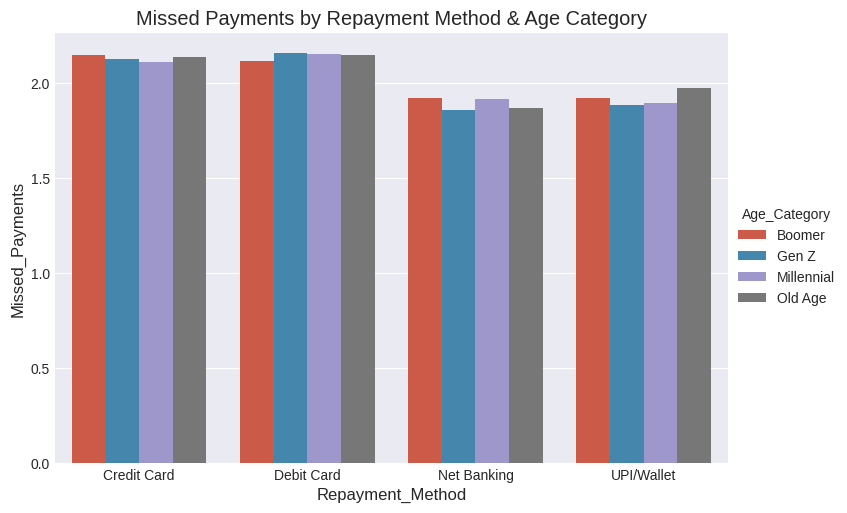

In [248]:
#33. Compare Missed Payments by Repayment Method & Age Category.

payment_age = df.groupby(['Repayment_Method', 'Age_Category'])[
              'Missed_Payments'].mean().reset_index()
sns.catplot(x='Repayment_Method',y='Missed_Payments',hue='Age_Category',
            data=payment_age,kind='bar',height=5,aspect=1.5)
plt.title('Missed Payments by Repayment Method & Age Category')
plt.show()

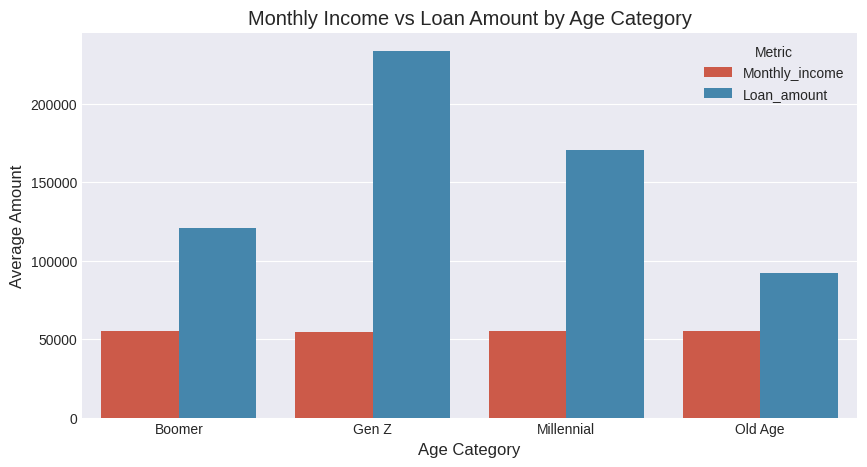

In [249]:
#34. Compare Average Monthly Income vs Loan Amount by Age Category.

income_loan_age = df.groupby('Age_Category')[
                  ['Monthly_income', 'Loan_amount']].mean().reset_index()
income_loan_melt = income_loan_age.melt(id_vars='Age_Category',
                                        var_name='Metric',value_name='Amount')
plt.figure(figsize=(10,5))
sns.barplot(x='Age_Category',y='Amount',hue='Metric',data=income_loan_melt)
plt.title('Monthly Income vs Loan Amount by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Average Amount')
plt.show()

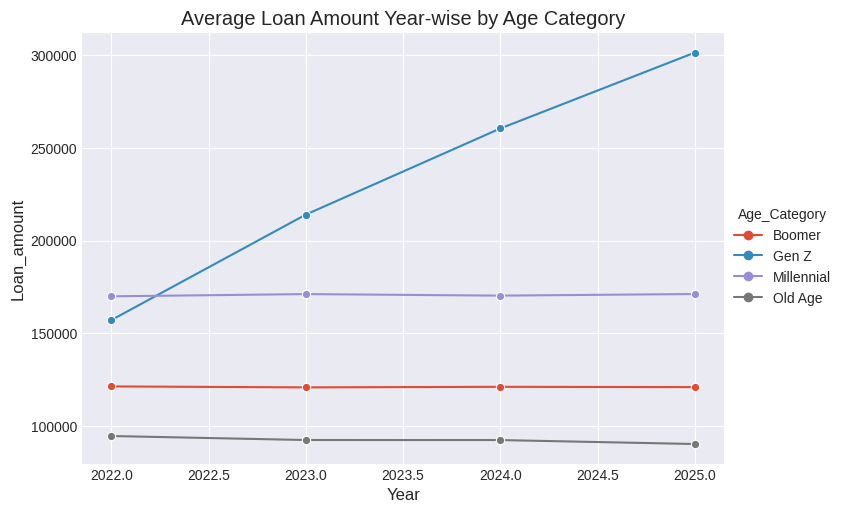

In [250]:
#35. Comapre Average Loan Amount Trends Year-wise by Age Category.

loan_year_age = df.groupby(['Year', 'Age_Category'])[
                'Loan_amount'].mean().reset_index()
sns.relplot(x='Year',y='Loan_amount',hue='Age_Category',
            kind='line',data=loan_year_age,marker='o',height=5,aspect=1.5)
plt.title('Average Loan Amount Year-wise by Age Category')
plt.show()

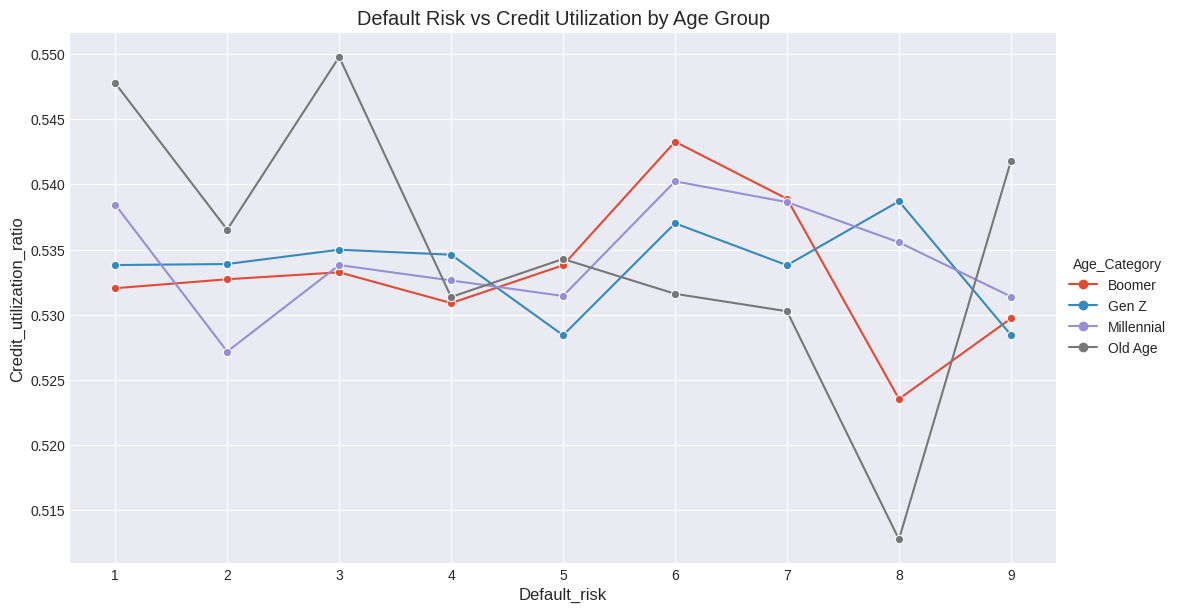

In [251]:
#36. compare Default Risk vs Credit Utilization Trend by Age Group.

risk_credit_age = df.groupby(['Default_risk', 'Age_Category'])[
                 'Credit_utilization_ratio'].mean().reset_index()
sns.relplot(x='Default_risk',y='Credit_utilization_ratio',hue='Age_Category',
            kind='line',data=risk_credit_age,marker='o',height=6,aspect=1.8)
plt.title('Default Risk vs Credit Utilization by Age Group')
plt.show()

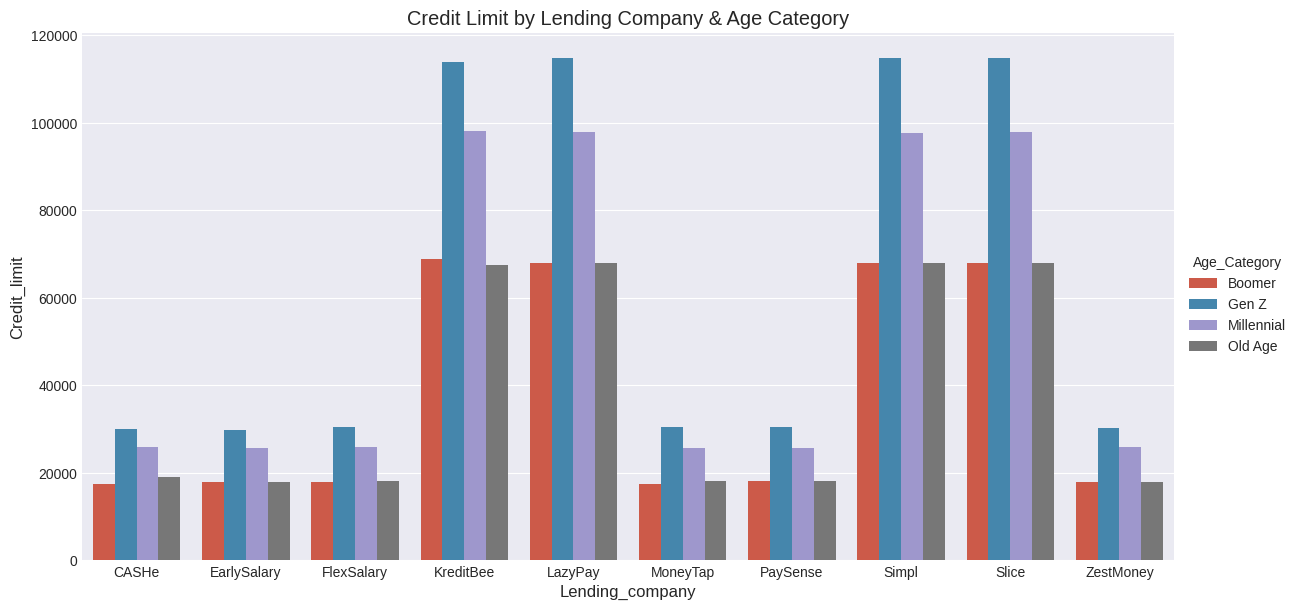

In [252]:
#37. Comapre Credit Limit by Lending Company & Age Category.

credit_limit_age = df.groupby(['Lending_company', 'Age_Category'])[
                  'Credit_limit'].mean().reset_index()
sns.catplot(x='Lending_company',y='Credit_limit',hue='Age_Category',
            data=credit_limit_age,kind='bar',height=6,aspect=2)
plt.title('Credit Limit by Lending Company & Age Category')
plt.show()

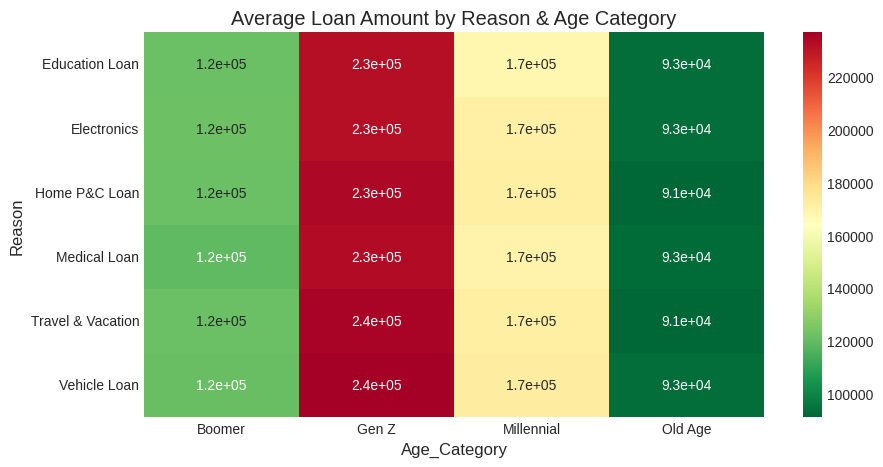

In [253]:
#38. Comapre Loan Amount by Reason & Age Category.

plt.figure(figsize=(10,5))
reason_age_loan = df.pivot_table(values='Loan_amount',index='Reason',
                                 columns='Age_Category',aggfunc='mean')
sns.heatmap(reason_age_loan,annot=True,cmap='RdYlGn_r')
plt.title('Average Loan Amount by Reason & Age Category')
plt.show()

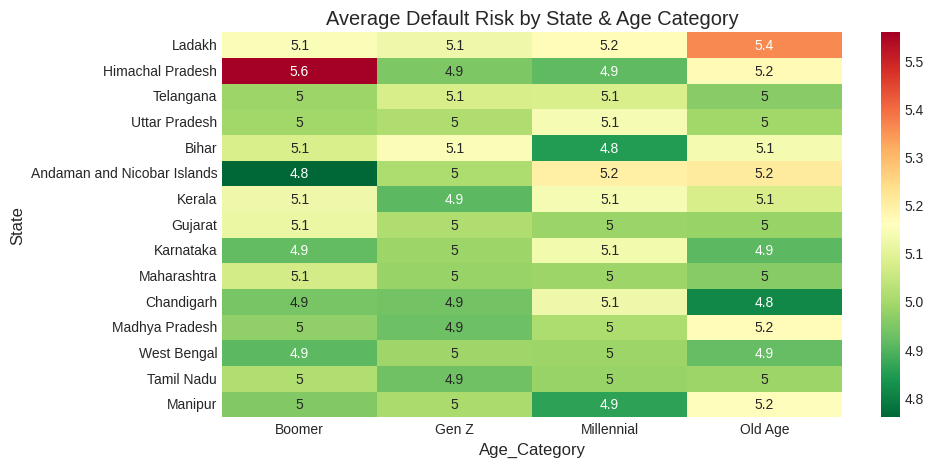

In [254]:
#39. Comapre Default Risk by State & Age Category.

plt.figure(figsize=(10,5))
state_age_risk = df.pivot_table(values='Default_risk',index='State',
                                columns='Age_Category',aggfunc='mean')
top_states = df.groupby('State')['Default_risk'].mean().sort_values(
             ascending=False).head(15).index
state_age_risk = state_age_risk.loc[top_states]
sns.heatmap(state_age_risk,annot=True,cmap='RdYlGn_r')
plt.title('Average Default Risk by State & Age Category')
plt.show()

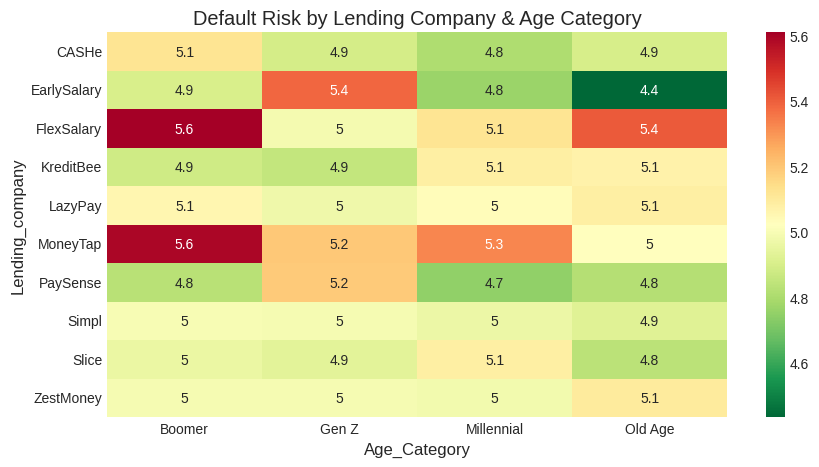

In [255]:
#40. Comapre Default Risk by Lending Company & Age Category.

plt.figure(figsize=(10,5))
company_age_risk = df.pivot_table(values='Default_risk',index='Lending_company',
                   columns='Age_Category',aggfunc='mean')
sns.heatmap(company_age_risk,annot=True,cmap='RdYlGn_r')
plt.title('Default Risk by Lending Company & Age Category')
plt.show()